<a href="https://colab.research.google.com/github/kayalaVamshi/AI-Story-Video-Generator/blob/main/AI_VIDEO_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q requests pillow moviepy gtts numpy
print("✅ Dependencies ready")

✅ Dependencies ready


In [9]:
import os
import json
import time
import base64
import io
import requests
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from moviepy.editor import AudioFileClip, ImageClip, CompositeVideoClip, concatenate_videoclips
from IPython.display import HTML, display
from gtts import gTTS
from google.colab import userdata

print("✅ Imports complete")

✅ Imports complete


In [10]:
USER_PROMPT = "A shy little ghost who discovers its true talent is making people laugh"  # @param {type:"string"}
NUM_SCENES = 5   # @param {type:"slider", min:2, max:5, step:1}
STYLE = "colorful Pixar-style animation, warm and friendly"  # @param {type:"string"}

print(f"Story idea: {USER_PROMPT}")
print(f"Number of scenes: {NUM_SCENES}")
print(f"Art style: {STYLE}")

Story idea: A shy little ghost who discovers its true talent is making people laugh
Number of scenes: 3
Art style: colorful Pixar-style animation, warm and friendly


In [11]:
# Make sure you have added your Google API key as a secret named 'GOOGLE_API_KEY'
API_KEY = userdata.get('GOOGLE_API_KEY')
if not API_KEY:
    raise ValueError("Please add your Google API key as a Colab secret named 'GOOGLE_API_KEY'")

WORKING_GEMINI_MODEL = "gemini-2.5-flash"

def call_gemini(prompt):
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{WORKING_GEMINI_MODEL}:generateContent?key={API_KEY}"
    headers = {'Content-Type': 'application/json'}
    data = {
        "contents": [{"parts": [{"text": prompt}]}],
        "generationConfig": {"responseMimeType": "application/json", "temperature": 0.7}
    }
    response = requests.post(url, headers=headers, json=data)
    response.raise_for_status()
    text = response.json()['candidates'][0]['content']['parts'][0]['text']
    # Clean markdown
    text = text.strip()
    if text.startswith("```json"):
        text = text[7:]
    if text.startswith("```"):
        text = text[3:]
    if text.endswith("```"):
        text = text[:-3]
    return json.loads(text)

def generate_story(idea, num_scenes, style):
    prompt = f"""
    Create a short children's story based on: "{idea}"
    Style: {style}
    Generate exactly {num_scenes} scenes. Return a valid JSON list of objects with keys:
    - "image_prompt": visual description for image generation (one sentence)
    - "audio_text": narration text for this scene (one sentence)
    - "character_desc": consistent description of the main character's appearance (same in all scenes)
    No extra text.
    """
    return call_gemini(prompt)

story = generate_story(USER_PROMPT, NUM_SCENES, STYLE)
print("Story generated successfully!")
for i, scene in enumerate(story):
    print(f"Scene {i+1}: {scene['audio_text'][:70]}...")

Story generated successfully!
Scene 1: Casper was a shy little ghost who loved to hide, especially when other...
Scene 2: One afternoon, while trying to sneak past a sleeping child, Casper tri...
Scene 3: Seeing the child's joyful laugh, Casper realized its true talent wasn'...


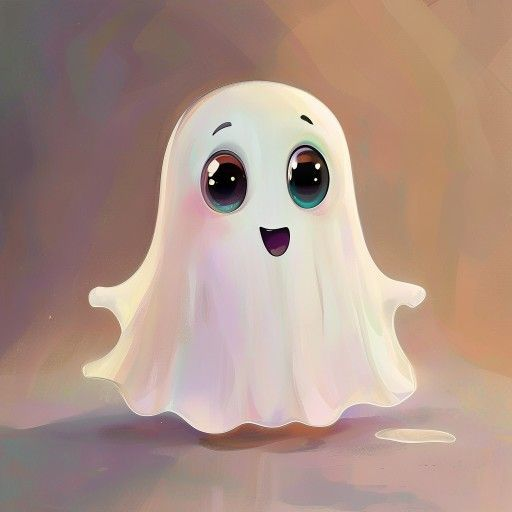

✅ Image generation works


In [12]:
def generate_image_pollinations(prompt, char_desc, scene_num):
    full_prompt = f"{prompt} Main character: {char_desc}. Art style: {STYLE}"
    url = f"https://image.pollinations.ai/prompt/{full_prompt.replace(' ', '%20')}?width=512&height=512&nologo=true"
    response = requests.get(url)
    if response.status_code == 200:
        img = Image.open(io.BytesIO(response.content))
        return img
    else:
        raise Exception(f"Image generation failed: {response.status_code}")

# Test
test_img = generate_image_pollinations("a cute ghost", "round, translucent ghost with big eyes", 1)
display(test_img)
print("✅ Image generation works")

In [13]:
def generate_audio(text, filename):
    tts = gTTS(text, lang='en', slow=False)
    tts.save(filename)
    return filename

In [14]:
temp_dir = "story_temp"
os.makedirs(temp_dir, exist_ok=True)

# Generate images and audio for all scenes
for idx, scene in enumerate(story):
    print(f"Generating assets for scene {idx+1}...")

    # Image
    img = generate_image_pollinations(scene['image_prompt'], scene['character_desc'], idx+1)
    img_path = os.path.join(temp_dir, f"scene_{idx+1}.png")
    img.save(img_path)

    # Audio
    audio_path = os.path.join(temp_dir, f"scene_{idx+1}.mp3")
    generate_audio(scene['audio_text'], audio_path)

    print(f"  ✅ Scene {idx+1} assets saved")

print("\nAll images and audio files generated successfully.")

Generating assets for scene 1...
  ✅ Scene 1 assets saved
Generating assets for scene 2...
  ✅ Scene 2 assets saved
Generating assets for scene 3...
  ✅ Scene 3 assets saved

All images and audio files generated successfully.


In [15]:
video_clips = []

# Try to download a nice font
try:
    !wget -q https://github.com/google/fonts/raw/main/ofl/worksans/WorkSans-Regular.ttf -O /tmp/font.ttf
    font_path = "/tmp/font.ttf"
except:
    font_path = None

for idx, scene in enumerate(story):
    print(f"\n📽️ Assembling scene {idx+1}")

    # Load image
    img_path = os.path.join(temp_dir, f"scene_{idx+1}.png")
    img = Image.open(img_path)
    img_width, img_height = img.size

    # Load audio
    audio_path = os.path.join(temp_dir, f"scene_{idx+1}.mp3")
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file missing: {audio_path}. Run Cell 7 first.")
    audio_clip = AudioFileClip(audio_path)

    # Create subtitle image using Pillow
    txt_img = Image.new('RGBA', (img_width, img_height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(txt_img)

    # Font
    font_size = 40
    try:
        if font_path:
            font = ImageFont.truetype(font_path, font_size)
        else:
            font = ImageFont.load_default()
    except:
        font = ImageFont.load_default()

    # Wrap text
    text = scene['audio_text']
    max_width = img_width - 100
    words = text.split()
    lines = []
    current_line = []
    for word in words:
        test_line = ' '.join(current_line + [word])
        bbox = draw.textbbox((0, 0), test_line, font=font)
        if bbox[2] - bbox[0] <= max_width:
            current_line.append(word)
        else:
            lines.append(' '.join(current_line))
            current_line = [word]
    lines.append(' '.join(current_line))
    wrapped_text = '\n'.join(lines)

    # Position
    bbox = draw.multiline_textbbox((0, 0), wrapped_text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    x = (img_width - text_width) // 2
    y = img_height - text_height - 30

    # Draw background
    padding = 10
    draw.rectangle(
        [x - padding, y - padding, x + text_width + padding, y + text_height + padding],
        fill=(0, 0, 0, 180)
    )
    draw.multiline_text(
        (x, y), wrapped_text,
        fill=(255, 255, 255, 255),
        font=font,
        align='center'
    )

    txt_np = np.array(txt_img)
    txt_clip = ImageClip(txt_np).set_duration(audio_clip.duration)

    # Combine
    img_clip = ImageClip(np.array(img)).set_duration(audio_clip.duration)
    final_clip = CompositeVideoClip([img_clip, txt_clip]).set_audio(audio_clip)
    video_clips.append(final_clip)

# Concatenate
final_video = concatenate_videoclips(video_clips)
output_path = "my_story_video.mp4"
final_video.write_videofile(output_path, fps=24, verbose=False)
print(f"\n✅ Video saved as {output_path}")


📽️ Assembling scene 1

📽️ Assembling scene 2

📽️ Assembling scene 3
Moviepy - Building video my_story_video.mp4.
MoviePy - Writing audio in my_story_videoTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video my_story_video.mp4



Moviepy - Done !
Moviepy - video ready my_story_video.mp4

✅ Video saved as my_story_video.mp4


In [16]:
def show_video(video_path):
    with open(video_path, "rb") as f:
        video_data = f.read()
    b64 = base64.b64encode(video_data).decode()
    return HTML(f'<video width="512" height="512" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

display(show_video(output_path))

from google.colab import files
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>